# Loading Data

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dir_path = '/Users/rachidaitjalloul/Desktop/Statistics Projects/instacart-market-basket-analysis'
order_products_train = pd.read_csv(f'{dir_path}/order_products__train.csv')
order_products_prior = pd.read_csv(f'{dir_path}/order_products__prior.csv')
orders      = pd.read_csv(f'{dir_path}/orders.csv')
products    = pd.read_csv(f'{dir_path}/products.csv')
aisles      = pd.read_csv(f'{dir_path}/aisles.csv')
departments = pd.read_csv(f'{dir_path}/departments.csv')

In [3]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [4]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [5]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [7]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [8]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [9]:
full_products = products.copy()
full_products = pd.merge(full_products, aisles,               on='aisle_id',      how='left')
full_products = pd.merge(full_products, departments,          on='department_id', how='left')
order_products_train = pd.merge(order_products_train, orders, on='order_id',      how='left')
order_products_prior = pd.merge(order_products_prior, orders, on='order_id',      how='left')
train         = pd.merge(order_products_train, full_products, on='product_id',    how='left')
test          = pd.merge(order_products_prior, full_products, on='product_id',    how='left')

In [10]:
full_products.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [11]:
del full_products
del order_products_train
del order_products_prior
train.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [12]:
test.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [13]:
print(f'train.shape: {train.shape}')
print(f'test.shape : {test.shape}')

train.shape: (1384617, 15)
test.shape : (32434489, 15)


In [14]:
train.dtypes

order_id                    int64
product_id                  int64
add_to_cart_order           int64
reordered                   int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
product_name               object
aisle_id                    int64
department_id               int64
aisle                      object
department                 object
dtype: object

In [15]:
data = pd.concat([train, test], ignore_index=True)
del train
del test

In [16]:
data.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.174104e+07,3.381911e+07,3.381911e+07
mean,1.710566e+06,2.557551e+04,8.367738e+00,5.900617e-01,1.029444e+05,1.713998e+01,2.737285e+00,1.343123e+01,1.136415e+01,7.121799e+01,9.918544e+00
std,9.874008e+05,1.409770e+04,7.139540e+00,4.918220e-01,5.946733e+04,1.749829e+01,2.093296e+00,4.246149e+00,8.940500e+00,3.819898e+01,6.281655e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,8.554130e+05,1.351900e+04,3.000000e+00,0.000000e+00,5.143500e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.000000e+00,3.100000e+01,4.000000e+00
50%,1.710660e+06,2.525600e+04,6.000000e+00,1.000000e+00,1.026260e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.000000e+00,8.300000e+01,9.000000e+00
75%,2.565587e+06,3.793500e+04,1.100000e+01,1.000000e+00,1.544120e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.500000e+01,1.070000e+02,1.600000e+01
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


In [ ]:
print(data.isnull().sum())

# Business Insights and EDA

In [20]:
reordered_products= data.loc[:, ['department', 'reordered']]
prods = reordered_products.groupby('department', as_index=False)['reordered'].mean()
prods.rename(columns={'reordered': 'reorder_rate'}, inplace=True)

In [21]:
prods

,department,reorder_rate
0,alcohol,0.571221
1,babies,0.577680
2,bakery,0.628381
3,beverages,0.653651
4,breakfast,0.561351
5,bulk,0.577090
6,canned goods,0.458639
7,dairy eggs,0.670161
8,deli,0.608130
9,dry goods pasta,0.462220


What we have done here is creating a new dataframe that determines the reorder_rate of each product. This statistic will help us determine the products that are very important to customers 

/var/folders/zb/_d8dsvp17n54wwjbqt8lknz80000gn/T/ipykernel_1037/2202581054.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="reorder_rate", y="department", data=merged_sorted, palette="viridis")


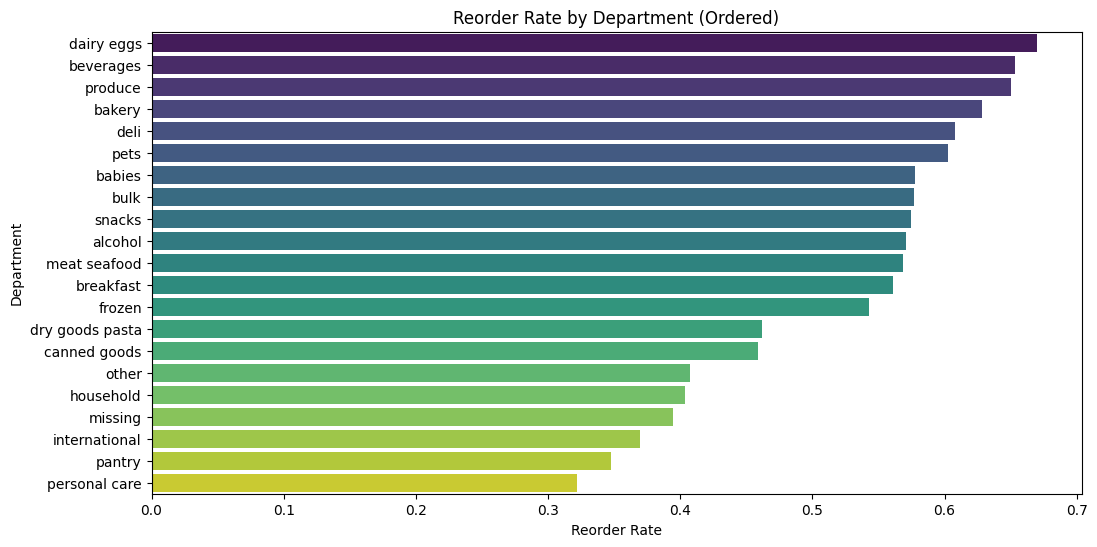

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_sorted = prods.sort_values(by="reorder_rate", ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x="reorder_rate", y="department", data=merged_sorted, palette="viridis")
plt.xlabel("Reorder Rate")
plt.ylabel("Department")
plt.title("Reorder Rate by Department (Ordered)")
plt.show()

In [23]:
buy_data = data.loc[:, ['user_id', 'order_id']]
buy_data

,user_id,order_id
0,112108,1
1,112108,1
2,112108,1
3,112108,1
4,112108,1
...,...,...
33819101,25247,3421083
33819102,25247,3421083
33819103,25247,3421083
33819104,25247,3421083


In [24]:
frequency_data = data.loc[:, ['user_id', 'days_since_prior_order']]
frequency_data = frequency_data.groupby('user_id', as_index=False)['days_since_prior_order'].median()
frequency_data.describe()

,user_id,days_since_prior_order
count,206209.000000,206209.000000
mean,103105.000000,15.326572
std,59527.555167,9.097779
min,1.000000,0.000000
25%,51553.000000,7.000000
50%,103105.000000,13.000000
75%,154657.000000,23.000000
max,206209.000000,30.000000


In [25]:
import seaborn as sns
data

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33819101,3421083,39678,6,1,25247,prior,24,2,6,21.0,Free & Clear Natural Dishwasher Detergent,74,17,dish detergents,household
33819102,3421083,11352,7,0,25247,prior,24,2,6,21.0,Organic Mini Sandwich Crackers Peanut Butter,78,19,crackers,snacks
33819103,3421083,4600,8,0,25247,prior,24,2,6,21.0,All Natural French Toast Sticks,52,1,frozen breakfast,frozen
33819104,3421083,24852,9,1,25247,prior,24,2,6,21.0,Banana,24,4,fresh fruits,produce


In [26]:
data.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'eval_set', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'product_name', 'aisle_id', 'department_id',
       'aisle', 'department'],
      dtype='object')

In [27]:
hour_data = data.loc[:, ['order_id', 'order_hour_of_day']]
day_data = data.loc[:, ['order_id', 'order_dow']]
hours = hour_data.groupby('order_id', as_index=False)['order_hour_of_day'].mean()
days=day_data.groupby('order_id', as_index=False)['order_dow'].mean()

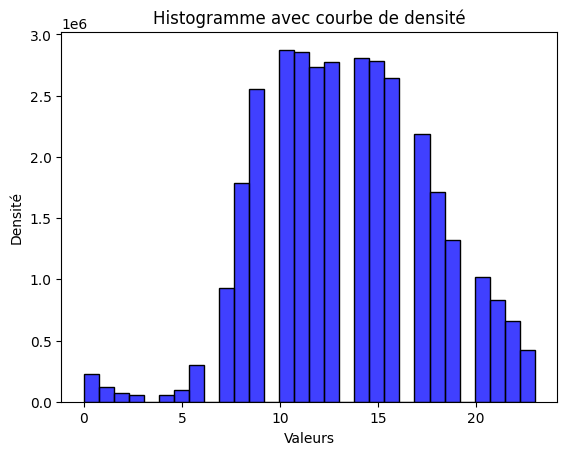

In [28]:
sns.histplot(hour_data['order_hour_of_day'], bins=24, color='b')
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.title("Histogramme avec courbe de densité")
plt.show()

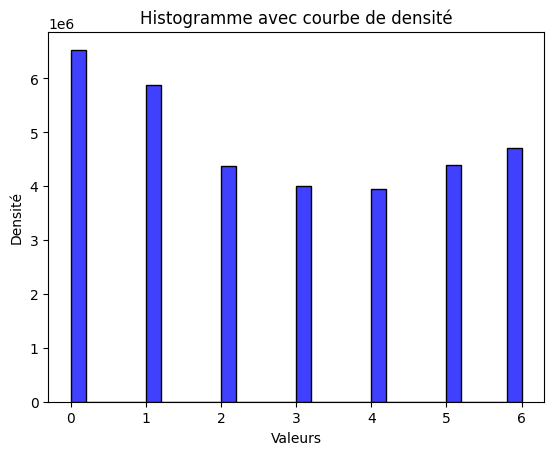

In [29]:
sns.histplot(day_data['order_dow'], bins=7, color='b')
plt.xlabel("Valeurs")
plt.ylabel("Densité")
plt.title("Histogramme avec courbe de densité")
plt.show()

In [30]:
reordered_products= data.loc[:, ['aisle', 'reordered','department']]
prods = reordered_products.groupby(['aisle', 'department'], as_index=False)['reordered'].mean()
prods.rename(columns={'reordered': 'reorder_rate'}, inplace=True)

In [31]:
prods

,aisle,department,reorder_rate
0,air fresheners candles,household,0.310737
1,asian foods,international,0.351274
2,baby accessories,babies,0.551500
3,baby bath body care,babies,0.294758
4,baby food formula,babies,0.589005
...,...,...,...
129,trash bags liners,household,0.336983
130,vitamins supplements,personal care,0.312176
131,water seltzer sparkling water,beverages,0.729930
132,white wines,alcohol,0.631928


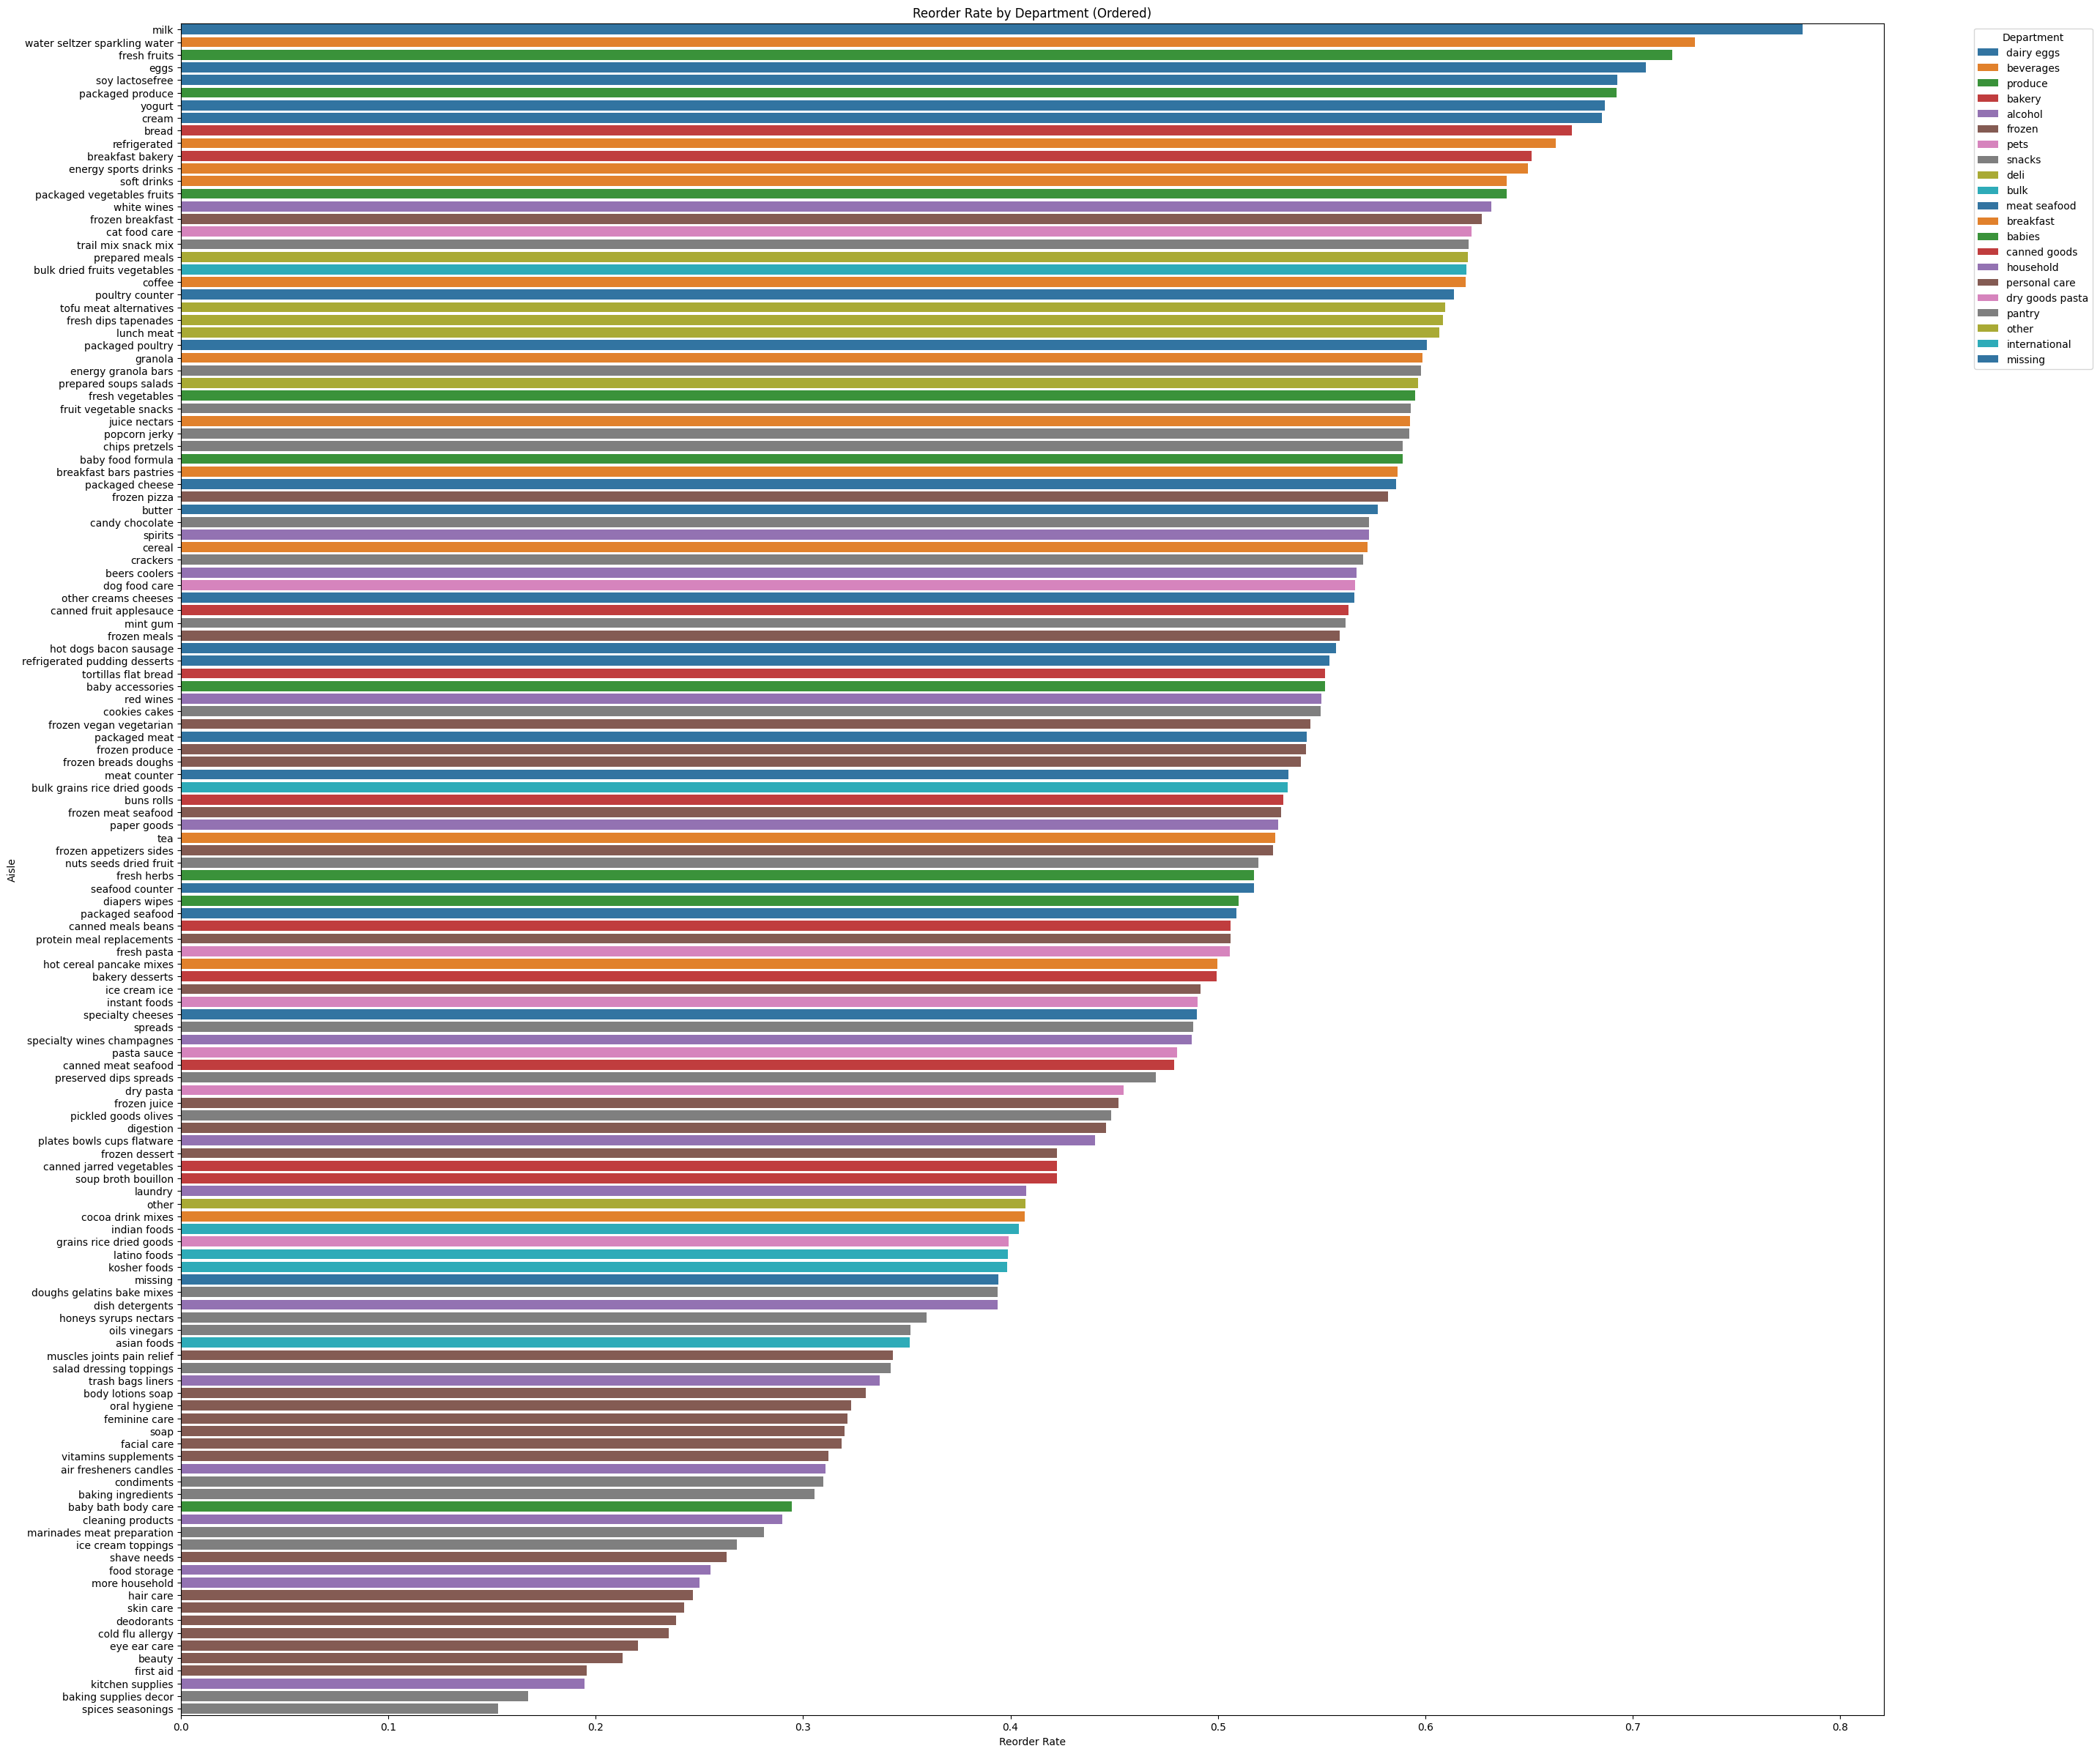

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_sorted = prods.sort_values(by="reorder_rate", ascending=False)
plt.figure(figsize=(30, 30))
sns.barplot(x="reorder_rate", y="aisle", hue="department", data=merged_sorted, dodge=False, palette="tab10")
plt.xlabel("Reorder Rate")
plt.ylabel("Aisle")
plt.title("Reorder Rate by Department (Ordered)")
plt.legend(title="Department", bbox_to_anchor=(1.05, 1), loc="upper left")  # Moves legend outside for clarity
plt.show()

In [33]:
data['days_since_prior_order'].fillna(-1, inplace=True)

/var/folders/zb/_d8dsvp17n54wwjbqt8lknz80000gn/T/ipykernel_1037/1663506240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['days_since_prior_order'].fillna(-1, inplace=True)


In [34]:
mine=data.copy()
mine=mine.drop(columns=['product_name','aisle','department'],axis=1)

In [35]:
mine.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
0,1,49302,1,1,112108,train,4,4,10,9.0,120,16
1,1,11109,2,1,112108,train,4,4,10,9.0,108,16
2,1,10246,3,0,112108,train,4,4,10,9.0,83,4
3,1,49683,4,0,112108,train,4,4,10,9.0,83,4
4,1,43633,5,1,112108,train,4,4,10,9.0,95,15


In [36]:
import pandas as pd
user_features = mine.groupby('user_id').agg({
    'days_since_prior_order': 'mean',
    'reordered': 'mean'
}).reset_index()

# Aggregate aisle preferences per user
user_aisle_stats = mine.groupby(['user_id', 'aisle_id']).agg(
    total_orders=('order_id', 'count'),
    reorder_rate=('reordered', 'mean')
).reset_index()

# Find the most frequently ordered aisle per user
most_frequent_aisle = user_aisle_stats.loc[user_aisle_stats.groupby('user_id')['total_orders'].idxmax()]
most_frequent_aisle = most_frequent_aisle[['user_id', 'aisle_id', 'total_orders']]
most_frequent_aisle.rename(columns={'aisle_id': 'favorite_aisle', 'total_orders': 'favorite_aisle_orders'}, inplace=True)

aisle_diversity = mine.groupby('user_id')['aisle_id'].nunique().reset_index()
aisle_diversity.rename(columns={'aisle_id': 'unique_aisles'}, inplace=True)

# Merge results
user_features = user_features.merge(most_frequent_aisle, on='user_id', how='left')
user_features = user_features.merge(aisle_diversity, on='user_id', how='left')
user_features=user_features.drop(columns=['favorite_aisle'],axis=1)

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_features.drop(columns=['user_id']))

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2D for visualization
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results into a DataFrame
user_features_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
user_features_pca['user_id'] = user_features['user_id']

Text(0.5, 1.0, 'Elbow Method for Optimal K')

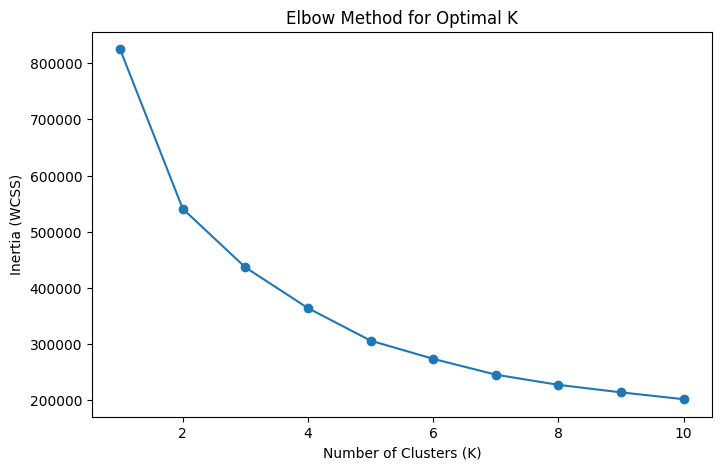

In [38]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
inertia = []
K_range = range(1, 11) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")

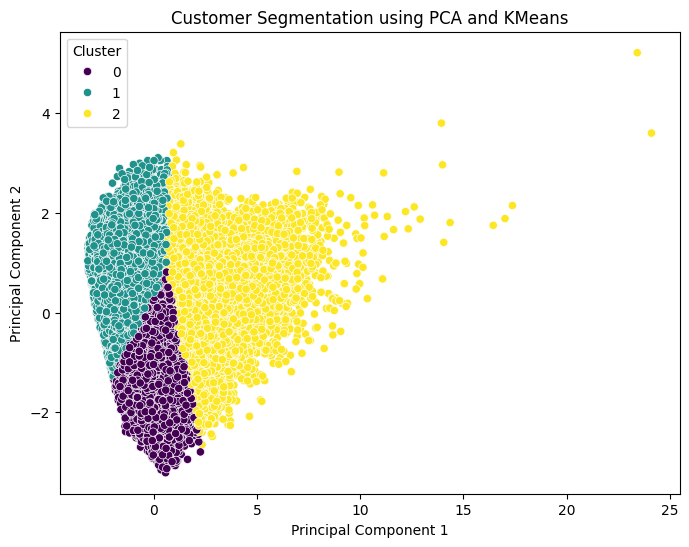

In [39]:
kmeans = KMeans(n_clusters=3, random_state=42)  
user_features_pca['Cluster'] = kmeans.fit_predict(X_pca)

# Visualize clusters
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=user_features_pca['PC1'], y=user_features_pca['PC2'], hue=user_features_pca['Cluster'], palette='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation using PCA and KMeans')
plt.legend(title='Cluster')
plt.show()


In [40]:
user_features_pca.head()

,PC1,PC2,user_id,Cluster
0,-0.301132,-0.387101,1,0
1,0.208951,0.825701,2,1
2,0.161966,-1.127450,3,0
3,-1.667789,-0.563290,4,1
4,-0.451895,-1.036327,5,0


In [41]:
cluster_1=user_features[user_features_pca['Cluster'] == 0]
cluster_2=user_features[user_features_pca['Cluster'] == 1]
cluster_3=user_features[user_features_pca['Cluster'] == 2]

In [42]:
cluster_1

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
0,1,17.757143,0.728571,15,13
2,3,10.068182,0.625000,19,16
4,5,9.130435,0.391304,10,17
5,6,5.285714,0.142857,4,8
6,7,12.418605,0.679070,31,34
...,...,...,...,...,...
206194,206195,9.643836,0.438356,10,27
206196,206197,10.895028,0.740331,29,23
206201,206202,11.696970,0.626263,30,29
206204,206205,9.470588,0.274510,9,20


In [43]:
cluster_1.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,77984.000000,77984.000000,77984.000000,77984.000000,77984.000000
mean,102982.426023,10.024905,0.476682,19.420779,22.312872
std,59578.635161,3.775432,0.182737,13.883770,11.267252
min,1.000000,-0.576923,0.000000,1.000000,1.000000
25%,51258.000000,7.257109,0.350877,9.000000,13.000000
50%,103286.000000,10.000000,0.483660,16.000000,21.000000
75%,154393.250000,12.722222,0.607407,27.000000,30.000000
max,206207.000000,25.283186,0.981132,113.000000,63.000000


In [44]:
cluster_2.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,86508.000000,86508.000000,86508.000000,86508.000000,86508.000000
mean,103329.994856,18.345344,0.312783,12.704524,24.501942
std,59518.993232,3.801417,0.154630,9.254352,12.190071
min,2.000000,6.263889,0.000000,1.000000,1.000000
25%,51996.000000,15.606061,0.200000,6.000000,15.000000
50%,103306.000000,18.233489,0.307692,10.000000,23.000000
75%,154972.500000,21.000000,0.421053,17.000000,33.000000
max,206209.000000,29.693069,0.909091,119.000000,82.000000


In [45]:
cluster_3.describe()

,user_id,days_since_prior_order,reordered,favorite_aisle_orders,unique_aisles
count,41717.000000,41717.000000,41717.000000,41717.000000,41717.000000
mean,102867.565717,8.996807,0.656651,83.236834,49.384639
std,59449.564743,3.580671,0.124045,58.181061,13.566584
min,17.000000,0.264668,0.166065,10.000000,1.000000
25%,51359.000000,6.410920,0.572016,46.000000,41.000000
50%,102394.000000,8.520788,0.665072,68.000000,49.000000
75%,154442.000000,11.262687,0.749235,102.000000,58.000000
max,206208.000000,25.431138,0.989637,1540.000000,102.000000


In [46]:
from scipy.stats import ttest_ind
t_stat1, p_value1 = ttest_ind(cluster_1['days_since_prior_order'], cluster_2['days_since_prior_order'], equal_var=False)
t_stat2, p_value2 = ttest_ind(cluster_2['days_since_prior_order'], cluster_3['days_since_prior_order'], equal_var=False)
t_stat3, p_value3 = ttest_ind(cluster_3['days_since_prior_order'], cluster_1['days_since_prior_order'], equal_var=False)

print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}")

T-statistic_1: -444.85734622014013, P-value_1: 0.0
T-statistic_2: 429.2190832885538, P-value_2: 0.0
T-statistic_3: -46.439173476708724, P-value_3: 0.0


In [47]:
from scipy.stats import ttest_ind
t_stat1, p_value1 = ttest_ind(cluster_1['unique_aisles'], cluster_2['unique_aisles'], equal_var=False)
t_stat2, p_value2 = ttest_ind(cluster_2['unique_aisles'], cluster_3['unique_aisles'], equal_var=False)
t_stat3, p_value3 = ttest_ind(cluster_3['unique_aisles'], cluster_1['unique_aisles'], equal_var=False)

print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}")

T-statistic_1: -37.84597623707741, P-value_1: 0.0
T-statistic_2: -317.81860170380946, P-value_2: 0.0
T-statistic_3: 348.3406141273081, P-value_3: 0.0


In [48]:
from scipy.stats import ttest_ind
t_stat1, p_value1 = ttest_ind(cluster_1['favorite_aisle_orders'], cluster_2['favorite_aisle_orders'], equal_var=False)
t_stat2, p_value2 = ttest_ind(cluster_2['favorite_aisle_orders'], cluster_3['favorite_aisle_orders'], equal_var=False)
t_stat3, p_value3 = ttest_ind(cluster_3['favorite_aisle_orders'], cluster_1['favorite_aisle_orders'], equal_var=False)

print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}")

T-statistic_1: 114.15041213845538, P-value_1: 0.0
T-statistic_2: -246.11023615403994, P-value_2: 0.0
T-statistic_3: 220.6931477257659, P-value_3: 0.0


In [49]:
from scipy.stats import ttest_ind
t_stat1, p_value1 = ttest_ind(cluster_1['reordered'], cluster_2['reordered'], equal_var=False)
t_stat2, p_value2 = ttest_ind(cluster_2['reordered'], cluster_3['reordered'], equal_var=False)
t_stat3, p_value3 = ttest_ind(cluster_3['reordered'], cluster_1['reordered'], equal_var=False)

print(f"T-statistic_1: {t_stat1}, P-value_1: {p_value1}")
print(f"T-statistic_2: {t_stat2}, P-value_2: {p_value2}")
print(f"T-statistic_3: {t_stat3}, P-value_3: {p_value3}")

T-statistic_1: 195.25656054244777, P-value_1: 0.0
T-statistic_2: -428.0841864053145, P-value_2: 0.0
T-statistic_3: 201.5833143334001, P-value_3: 0.0


The first cluster represents casual shoppers who have some consistency in their purchases but also explore different products. The second cluster represents occasional shoppers who are less loyal and explore different products. They might shop in bulk or irregularly. And the third cluster represents frequent shoppers who have strong preferences and reorder their favorite items consistently, they are likely highly engaged customers

# Market Basket Analysis

In [50]:
import pandas as pd

# 1. Group by 'order_id' and aggregate 'product_name' into lists
transaction_df = data.groupby('order_id')['aisle'].apply(list).reset_index(name='aisle')

# 2. Display the resulting DataFrame
print(transaction_df.head())

transactions = transaction_df['aisle'].tolist()
print("\nExample Transactions List (first 5):")
print(transactions[:5])

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True) # Adjust min_support as needed

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7) # Adjust metric and min_threshold as needed

   order_id                                              aisle
0         1  [yogurt, other creams cheeses, fresh vegetable...
1         2  [eggs, fresh vegetables, spices seasonings, oi...
2         3  [yogurt, soy lactosefree, packaged vegetables ...
3         4  [breakfast bakery, cold flu allergy, energy gr...
4         5  [fresh fruits, salad dressing toppings, prepar...

Example Transactions List (first 5):
[['yogurt', 'other creams cheeses', 'fresh vegetables', 'fresh vegetables', 'canned meat seafood', 'fresh fruits', 'fresh fruits', 'packaged cheese'], ['eggs', 'fresh vegetables', 'spices seasonings', 'oils vinegars', 'baking ingredients', 'fresh vegetables', 'doughs gelatins bake mixes', 'spreads', 'packaged vegetables fruits'], ['yogurt', 'soy lactosefree', 'packaged vegetables fruits', 'packaged vegetables fruits', 'soy lactosefree', 'fresh vegetables', 'poultry counter', 'bread'], ['breakfast bakery', 'cold flu allergy', 'energy granola bars', 'breakfast bars pastries', 'br

In [51]:
print("\nFrequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
rules.head()


Frequent Itemsets:
      support                                           itemsets
0    0.076715                               (baking ingredients)
1    0.163958                                            (bread)
2    0.068667                                 (breakfast bakery)
3    0.074770                                           (butter)
4    0.069390                                  (candy chocolate)
..        ...                                                ...
151  0.051020         (yogurt, packaged vegetables fruits, milk)
152  0.050928  (packaged cheese, packaged vegetables fruits, ...
153  0.062319  (fresh fruits, fresh vegetables, packaged vege...
154  0.067929  (fresh fruits, packaged cheese, fresh vegetabl...
155  0.076052  (fresh fruits, fresh vegetables, packaged vege...

[156 rows x 2 columns]

Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(canned jarred vegetables),(fresh vegetables),0.073715,0.444341,0.056155,0.761785,1.714413,1.0,0.023400,2.332590,0.449872,0.121573,0.571292,0.444081
1,(canned meals beans),(fresh vegetables),0.069799,0.444341,0.050033,0.716821,1.613222,1.0,0.019019,1.962218,0.408645,0.107805,0.490373,0.414711
2,(fresh dips tapenades),(fresh fruits),0.098128,0.556755,0.069495,0.708205,1.272023,1.0,0.014861,1.519030,0.237119,0.118716,0.341685,0.416513
3,(fresh herbs),(fresh fruits),0.093564,0.556755,0.070103,0.749254,1.345752,1.0,0.018011,1.767706,0.283441,0.120823,0.434295,0.437584
4,(fresh vegetables),(fresh fruits),0.444341,0.556755,0.318137,0.715974,1.285977,1.0,0.070748,1.560581,0.400212,0.465821,0.359213,0.643694


In [52]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(canned jarred vegetables),(fresh vegetables),0.073715,0.444341,0.056155,0.761785,1.714413,1.0,0.023400,2.332590,0.449872,0.121573,0.571292,0.444081
1,(canned meals beans),(fresh vegetables),0.069799,0.444341,0.050033,0.716821,1.613222,1.0,0.019019,1.962218,0.408645,0.107805,0.490373,0.414711
2,(fresh dips tapenades),(fresh fruits),0.098128,0.556755,0.069495,0.708205,1.272023,1.0,0.014861,1.519030,0.237119,0.118716,0.341685,0.416513
3,(fresh herbs),(fresh fruits),0.093564,0.556755,0.070103,0.749254,1.345752,1.0,0.018011,1.767706,0.283441,0.120823,0.434295,0.437584
4,(fresh vegetables),(fresh fruits),0.444341,0.556755,0.318137,0.715974,1.285977,1.0,0.070748,1.560581,0.400212,0.465821,0.359213,0.643694
5,(frozen produce),(fresh fruits),0.123301,0.556755,0.089555,0.726313,1.304546,1.0,0.020907,1.619531,0.266283,0.151660,0.382537,0.443583
6,(packaged vegetables fruits),(fresh fruits),0.367445,0.556755,0.270937,0.737354,1.324378,1.0,0.066360,1.687614,0.387205,0.414744,0.407448,0.611995
7,(yogurt),(fresh fruits),0.263093,0.556755,0.187954,0.714404,1.283156,1.0,0.041476,1.551998,0.299456,0.297446,0.355669,0.525996
8,(fresh herbs),(fresh vegetables),0.093564,0.444341,0.079047,0.844839,1.901328,1.0,0.037472,3.581166,0.522984,0.172268,0.720761,0.511368
9,"(fresh vegetables, bread)",(fresh fruits),0.091134,0.556755,0.072142,0.791606,1.421820,1.0,0.021403,2.126952,0.326424,0.125302,0.529844,0.460591


# Simple Logistic Regression

In [16]:
mine=data.copy()
mine.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [17]:
mine.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.381911e+07,3.174104e+07,3.381911e+07,3.381911e+07
mean,1.710566e+06,2.557551e+04,8.367738e+00,5.900617e-01,1.029444e+05,1.713998e+01,2.737285e+00,1.343123e+01,1.136415e+01,7.121799e+01,9.918544e+00
std,9.874008e+05,1.409770e+04,7.139540e+00,4.918220e-01,5.946733e+04,1.749829e+01,2.093296e+00,4.246149e+00,8.940500e+00,3.819898e+01,6.281655e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,8.554130e+05,1.351900e+04,3.000000e+00,0.000000e+00,5.143500e+04,5.000000e+00,1.000000e+00,1.000000e+01,5.000000e+00,3.100000e+01,4.000000e+00
50%,1.710660e+06,2.525600e+04,6.000000e+00,1.000000e+00,1.026260e+05,1.100000e+01,3.000000e+00,1.300000e+01,8.000000e+00,8.300000e+01,9.000000e+00
75%,2.565587e+06,3.793500e+04,1.100000e+01,1.000000e+00,1.544120e+05,2.400000e+01,5.000000e+00,1.600000e+01,1.500000e+01,1.070000e+02,1.600000e+01
max,3.421083e+06,4.968800e+04,1.450000e+02,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


In [18]:
dummies = pd.get_dummies(mine['order_dow'], dtype=int,prefix='dow')
mine = pd.concat([mine, dummies], axis=1)
dummies_2 = pd.get_dummies(mine['order_hour_of_day'], dtype=int,prefix='hod')
mine = pd.concat([mine, dummies_2], axis=1)

In [19]:
mine=mine.drop(columns=['order_id','aisle','department','product_name','eval_set'],axis=1)

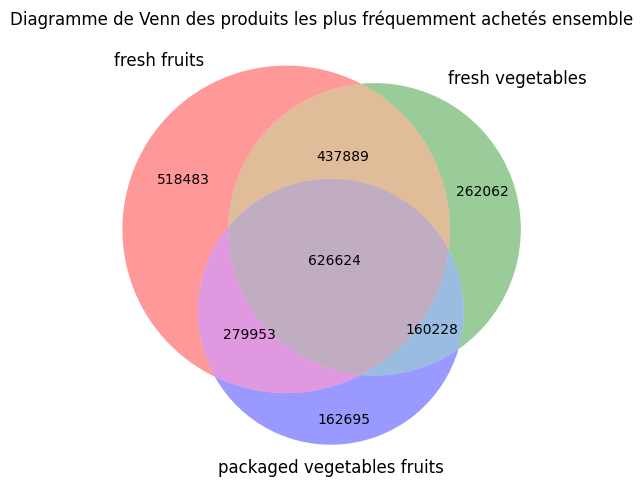

In [63]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from itertools import combinations

# Sélection des 3 produits les plus achetés
top_products = data['aisle'].value_counts().index[:10]

# Création des ensembles d'achats
sets = {product: set(data[data['aisle'] == product]['order_id']) for product in top_products}

# Création du diagramme de Venn
plt.figure(figsize=(6,6))
venn3([sets[top_products[0]], sets[top_products[1]], sets[top_products[2]]], 
      set_labels=top_products)
plt.title("Diagramme de Venn des produits les plus fréquemment achetés ensemble")
plt.show()


In [67]:
import seaborn as sns
import pandas as pd

# Création d'une table croisée (co-occurrence des produits dans les commandes)
product_co_occurrence = pd.crosstab(data['order_id'], data['aisle'])

KeyboardInterrupt: 

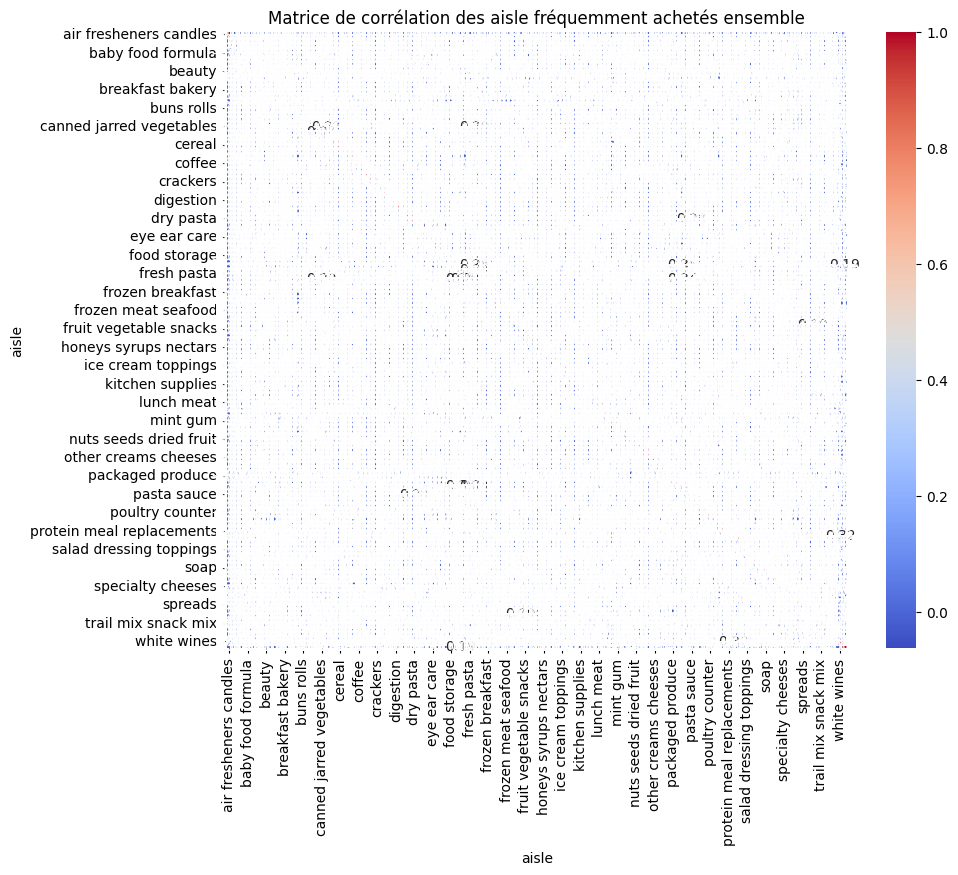

In [65]:
# Calcul de la matrice de corrélation (corrélation entre les achats de produits)
product_co_occurrence.head()
correlation_matrix = product_co_occurrence.corr()

# Affichage sous forme de heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Matrice de corrélation des aisle fréquemment achetés ensemble")
plt.show()

In [20]:
mine.head()

,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id,...,hod_14,hod_15,hod_16,hod_17,hod_18,hod_19,hod_20,hod_21,hod_22,hod_23
0,49302,1,1,112108,4,4,10,9.0,120,16,...,0,0,0,0,0,0,0,0,0,0
1,11109,2,1,112108,4,4,10,9.0,108,16,...,0,0,0,0,0,0,0,0,0,0
2,10246,3,0,112108,4,4,10,9.0,83,4,...,0,0,0,0,0,0,0,0,0,0
3,49683,4,0,112108,4,4,10,9.0,83,4,...,0,0,0,0,0,0,0,0,0,0
4,43633,5,1,112108,4,4,10,9.0,95,15,...,0,0,0,0,0,0,0,0,0,0


In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [1]:
del data
X=mine.drop(columns=['reordered'],axis=1)
y=mine["reordered"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:\n', classification_report(y_test, y_pred))

NameError: name 'data' is not defined